In [1]:
# ── Cell 1: Import Libraries ──────────────────────────────────────────────────
# We import all libraries we need for EDA upfront
# This is a best practice — makes dependencies clear at the top
# Running this in JupyterLab so we can see outputs inline

import pandas as pd        # Data manipulation
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns      # Statistical visualizations
import warnings
warnings.filterwarnings('ignore')

# Display settings
# Makes numbers readable (no scientific notation)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# ── Cell 2: Load Dataset ──────────────────────────────────────────────────────
# We load the raw dataset we generated earlier
# We're in JupyterLab running inside Docker
# /app maps to our project folder on laptop
# So data/raw/bank_churn_2M.csv is accessible directly

import time

print("Loading 2M row dataset... this may take 30-60 seconds ⏳")
start = time.time()

df = pd.read_csv('/app/data/raw/bank_churn_2M.csv')

end = time.time()
print(f"✅ Dataset loaded in {end-start:.1f} seconds!")
print(f"\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Column names:")
print(list(df.columns))

Loading 2M row dataset... this may take 30-60 seconds ⏳
✅ Dataset loaded in 23.8 seconds!

📊 Shape: 2,000,500 rows × 44 columns

📋 Column names:
['CustomerId', 'Surname', 'Phone', 'Email', 'AadhaarLast4', 'Geography', 'City', 'RegionCode', 'Gender', 'Age', 'Occupation', 'CreditScore', 'Balance', 'SavingsAccountBalance', 'InvestmentAccountBalance', 'TotalProductValue', 'EstimatedSalary', 'RewardPoints', 'OverdraftCount', 'MissedPayments', 'CustomerSegment', 'RiskCategory', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'LoanType', 'Channel', 'PreferredContactMethod', 'NumComplaints', 'NumTransactionsLast3Months', 'AvgMonthlyBalance', 'NumLogins', 'AccountOpenDate', 'LastTransactionDate', 'LastLoginDate', 'LastComplaintDate', 'RecordTimestamp', 'DataSource', 'DataQualityFlag', 'ModelVersion', 'PreviousModelScore', 'CampaignResponseHistory', 'Exited']


In [3]:
# ── Cell 3: Basic Dataset Info ────────────────────────────────────────────────
# First thing in any EDA — understand what you're working with
# This is run in JupyterLab so we can see all outputs inline
# In interviews: "first I looked at shape, dtypes, and missing values"

print("=" * 50)
print("1. BASIC INFO")
print("=" * 50)
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("2. DATA TYPES")
print("=" * 50)
print(df.dtypes.value_counts())
print("\nPer column:")
print(df.dtypes)

print("\n" + "=" * 50)
print("3. MEMORY USAGE")
print("=" * 50)
# In prod — memory optimization is critical for large datasets
# Interview topic: how do you reduce memory usage of a large dataframe?
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Total memory: {memory_mb:.1f} MB")

print("\n" + "=" * 50)
print("4. FIRST 5 ROWS")
print("=" * 50)
df.head()

1. BASIC INFO
Rows:    2,000,500
Columns: 44

2. DATA TYPES
object     19
int64      16
float64     9
Name: count, dtype: int64

Per column:
CustomerId                      int64
Surname                        object
Phone                          object
Email                          object
AadhaarLast4                    int64
Geography                      object
City                           object
RegionCode                      int64
Gender                         object
Age                             int64
Occupation                     object
CreditScore                   float64
Balance                       float64
SavingsAccountBalance         float64
InvestmentAccountBalance      float64
TotalProductValue             float64
EstimatedSalary               float64
RewardPoints                    int64
OverdraftCount                  int64
MissedPayments                  int64
CustomerSegment                object
RiskCategory                   object
Tenure                 

,CustomerId,Surname,Phone,Email,AadhaarLast4,Geography,City,RegionCode,Gender,Age,Occupation,CreditScore,Balance,SavingsAccountBalance,InvestmentAccountBalance,TotalProductValue,EstimatedSalary,RewardPoints,OverdraftCount,MissedPayments,CustomerSegment,RiskCategory,Tenure,NumOfProducts,HasCrCard,IsActiveMember,LoanType,Channel,PreferredContactMethod,NumComplaints,NumTransactionsLast3Months,AvgMonthlyBalance,NumLogins,AccountOpenDate,LastTransactionDate,LastLoginDate,LastComplaintDate,RecordTimestamp,DataSource,DataQualityFlag,ModelVersion,PreviousModelScore,CampaignResponseHistory,Exited
0,11885899,Wilson,+91-8235045535,cust11885899@yahoo.com,7842,Spain,Palma,3,Male,27,Manager,508.00,119055.86,35099.50,0.00,154155.36,41377.54,39081,0,0,Basic,Medium,10,1,0,1,Education,Phone,Email,0,9,122664.10,11.00,2015-10-17,2023-05-13,2023-10-14,2023-08-13,2023-12-21,API,0,v2.0,0.20,0,0
1,10343021,Thomas,+91-7178809396,cust10343021@outlook.com,9331,Germany,Cologne,2,Male,39,Professor,460.00,0.00,0.00,0.00,0.00,96017.72,23893,0,0,Regular,High,7,1,0,1,Auto,Mobile,App,2,8,0.00,12.00,2012-04-13,NaN,2023-11-17,2023-11-06,2023-12-15,Branch,0,v1.1,0.01,0,0
2,10701400,Smith,+91-8805215496,cust10701400@yahoo.com,3595,Spain,Seville,3,Female,45,Banker,797.00,NaN,6539.21,29487.10,49869.08,76704.38,31817,1,0,Regular,Low,4,2,1,1,Auto,Mobile,App,1,10,16426.52,20.00,2014-12-09,2023-01-28,2023-12-23,2023-09-30,2023-12-07,Mobile,0,v2.0,0.83,0,0
3,10225584,Taylor,+91-8315918156,cust10225584@gmail.com,4308,France,Nice,1,Female,52,Pilot,748.00,0.00,0.00,43016.85,43016.85,99927.69,39122,0,1,Regular,Low,10,2,1,1,NaN,Phone,Phone,1,5,0.00,12.00,2020-09-01,2023-09-21,2023-07-14,2022-09-04,2023-12-31,Mobile,0,v1.1,0.33,0,0
4,11544695,Jones,+91-8942411604,cust11544695@yahoo.com,5484,France,Toulon,1,Female,44,Developer,694.00,0.00,0.00,0.00,0.00,51587.30,15610,0,0,Regular,Low,3,1,0,0,Education,ATM,Email,1,3,0.00,16.00,2013-07-08,2023-01-31,2023-07-17,2023-07-11,2023-12-06,API,0,v2.0,0.83,1,1


MISSING VALUE ANALYSIS
                     Missing Count  Missing %
LoanType                    699571      34.97
Occupation                   99380       4.97
LastTransactionDate          80426       4.02
City                         59972       3.00
Balance                      60105       3.00
NumLogins                    59659       2.98
CreditScore                  40121       2.01
EstimatedSalary              40182       2.01

Total columns with missing values: 8
Total missing cells: 1,139,416


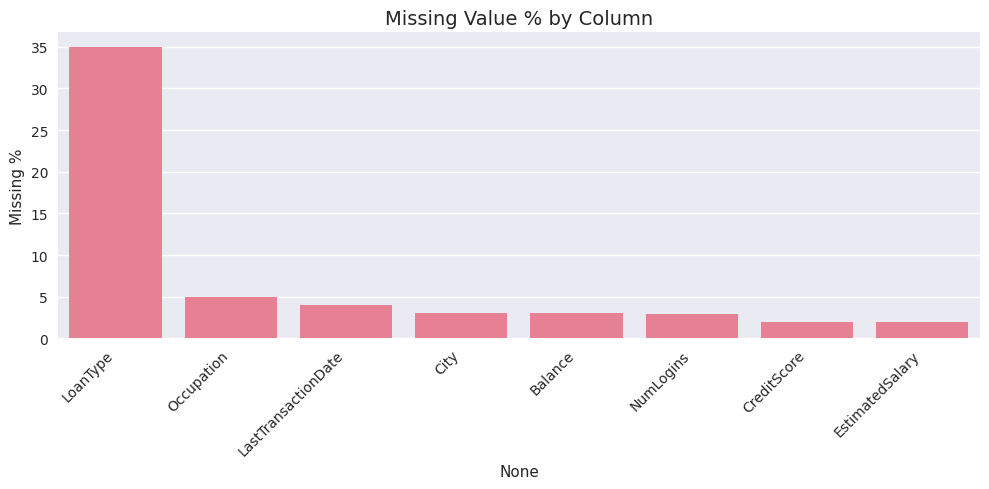

✅ Missing value chart saved!


In [5]:
# ── Cell 4: Missing Value Analysis ───────────────────────────────────────────
# Run in JupyterLab to see inline output
# In interviews: "first thing I check after loading is missing values"
# Interview topic: MCAR vs MAR vs MNAR — type of missingness matters!

print("=" * 50)
print("MISSING VALUE ANALYSIS")
print("=" * 50)

# Count and percentage of missing values per column
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

# Only show columns that have missing values
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(missing)
print(f"\nTotal columns with missing values: {len(missing)}")
print(f"Total missing cells: {df.isnull().sum().sum():,}")

# Visualize missing values
# We use a bar chart — easy to explain in interviews
plt.figure(figsize=(10, 5))
sns.barplot(x=missing.index, y='Missing %', data=missing)
plt.title('Missing Value % by Column', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing %')
plt.tight_layout()
plt.savefig('/app/notebooks/missing_values.png', dpi=100)
plt.show()
print("✅ Missing value chart saved!")

In [6]:
# ── Cell 5: Duplicate Analysis ────────────────────────────────────────────────
# Run in JupyterLab
# We deliberately injected 500 duplicates — let's find them
# Interview topic: how do you identify duplicates in prod?
# Exact duplicates vs near duplicates (fuzzy matching)

print("=" * 50)
print("DUPLICATE ANALYSIS")
print("=" * 50)

# Check exact duplicates across all columns
total_dups = df.duplicated().sum()
print(f"Total exact duplicate rows: {total_dups:,}")

# Check duplicates based on CustomerId only
# In prod — same CustomerId appearing twice is a data pipeline issue
id_dups = df.duplicated(subset=['CustomerId']).sum()
print(f"Duplicate CustomerIds: {id_dups:,}")

# Show sample duplicate rows
print(f"\nSample duplicate rows:")
dup_mask = df.duplicated(keep=False)
df[dup_mask].sort_values('CustomerId').head(4)

DUPLICATE ANALYSIS
Total exact duplicate rows: 500
Duplicate CustomerIds: 500

Sample duplicate rows:


,CustomerId,Surname,Phone,Email,AadhaarLast4,Geography,City,RegionCode,Gender,Age,Occupation,CreditScore,Balance,SavingsAccountBalance,InvestmentAccountBalance,TotalProductValue,EstimatedSalary,RewardPoints,OverdraftCount,MissedPayments,CustomerSegment,RiskCategory,Tenure,NumOfProducts,HasCrCard,IsActiveMember,LoanType,Channel,PreferredContactMethod,NumComplaints,NumTransactionsLast3Months,AvgMonthlyBalance,NumLogins,AccountOpenDate,LastTransactionDate,LastLoginDate,LastComplaintDate,RecordTimestamp,DataSource,DataQualityFlag,ModelVersion,PreviousModelScore,CampaignResponseHistory,Exited
384,10003456,Brown,+91-7037377483,cust10003456@gmail.com,7259,France,Toulon,1,Female,32,Accountant,705.00,8968.12,1812.58,26911.71,37692.41,91929.05,37185,0,0,Regular,Low,4,2,1,1,NaN,Phone,Email,0,6,10479.60,17.00,2020-07-07,2023-08-22,2023-07-22,2023-05-07,2023-12-17,Mobile,0,v1.0,0.64,0,0
1651348,10003456,Brown,+91-7037377483,cust10003456@gmail.com,7259,France,Toulon,1,Female,32,Accountant,705.00,8968.12,1812.58,26911.71,37692.41,91929.05,37185,0,0,Regular,Low,4,2,1,1,NaN,Phone,Email,0,6,10479.60,17.00,2020-07-07,2023-08-22,2023-07-22,2023-05-07,2023-12-17,Mobile,0,v1.0,0.64,0,0
345719,10010865,Williams,+91-8329157749,cust10010865@yahoo.com,7774,France,Saint-Etienne,1,Female,45,NaN,595.00,65529.69,19621.95,0.00,85151.64,12142.69,32568,0,0,Basic,Medium,2,1,1,1,Personal,Mobile,Phone,0,12,72004.29,16.00,2016-01-30,2023-05-13,2023-07-12,2023-08-24,2023-12-29,API,0,v2.0,0.12,0,0
10689,10010865,Williams,+91-8329157749,cust10010865@yahoo.com,7774,France,Saint-Etienne,1,Female,45,NaN,595.00,65529.69,19621.95,0.00,85151.64,12142.69,32568,0,0,Basic,Medium,2,1,1,1,Personal,Mobile,Phone,0,12,72004.29,16.00,2016-01-30,2023-05-13,2023-07-12,2023-08-24,2023-12-29,API,0,v2.0,0.12,0,0


TARGET VARIABLE — CHURN DISTRIBUTION
Not Churned (0): 1,709,229 (85.4%)
Churned     (1): 291,271 (14.6%)

Imbalance ratio: 5.9:1


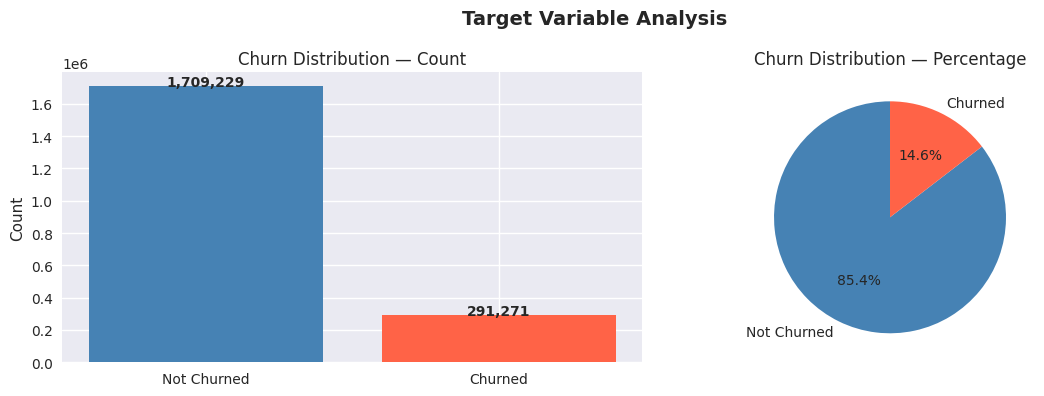


✅ Churn distribution chart saved!

⚠️  Class imbalance detected!
We will handle this later using SMOTE / class weights / threshold tuning


In [7]:
# ── Cell 6: Target Variable Analysis ─────────────────────────────────────────
# Run in JupyterLab to see charts inline
# Target variable = what we're trying to predict (Exited = churned or not)
# Interview topic: why is class imbalance a problem?
# If 85% are 0 and 15% are 1, model can score 85% accuracy by predicting all 0!

print("=" * 50)
print("TARGET VARIABLE — CHURN DISTRIBUTION")
print("=" * 50)

# Count and percentage
churn_counts = df['Exited'].value_counts()
churn_pct    = df['Exited'].value_counts(normalize=True) * 100

print(f"Not Churned (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"Churned     (1): {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")
print(f"\nImbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Churn Distribution — Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['Not Churned', 'Churned'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Churn Distribution — Percentage')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/app/notebooks/churn_distribution.png', dpi=100)
plt.show()

print("\n✅ Churn distribution chart saved!")
print("\n⚠️  Class imbalance detected!")
print("We will handle this later using SMOTE / class weights / threshold tuning")

NUMERICAL FEATURES — DESCRIPTIVE STATISTICS
             Age  CreditScore    Balance  EstimatedSalary     Tenure  \
count 2000500.00   1960379.00 1940395.00       1960318.00 2000500.00   
mean       37.78       649.04   44959.43         81901.43       5.00   
std        11.54       103.23   57970.06         49174.76       3.16   
min        10.00       150.00       0.00          1000.00       0.00   
25%        29.00       582.00       0.00         59666.48       2.00   
50%        38.00       650.00   24363.16         80016.44       5.00   
75%        46.00       717.00   65793.96        100403.10       8.00   
max       100.00      1000.00  500000.00        900000.00      10.00   

       NumOfProducts  RewardPoints  NumComplaints  NumTransactionsLast3Months  \
count     2000500.00    2000500.00     2000500.00                  2000500.00   
mean            1.80      25000.55           0.40                        8.00   
std             0.81      14435.91           0.63               

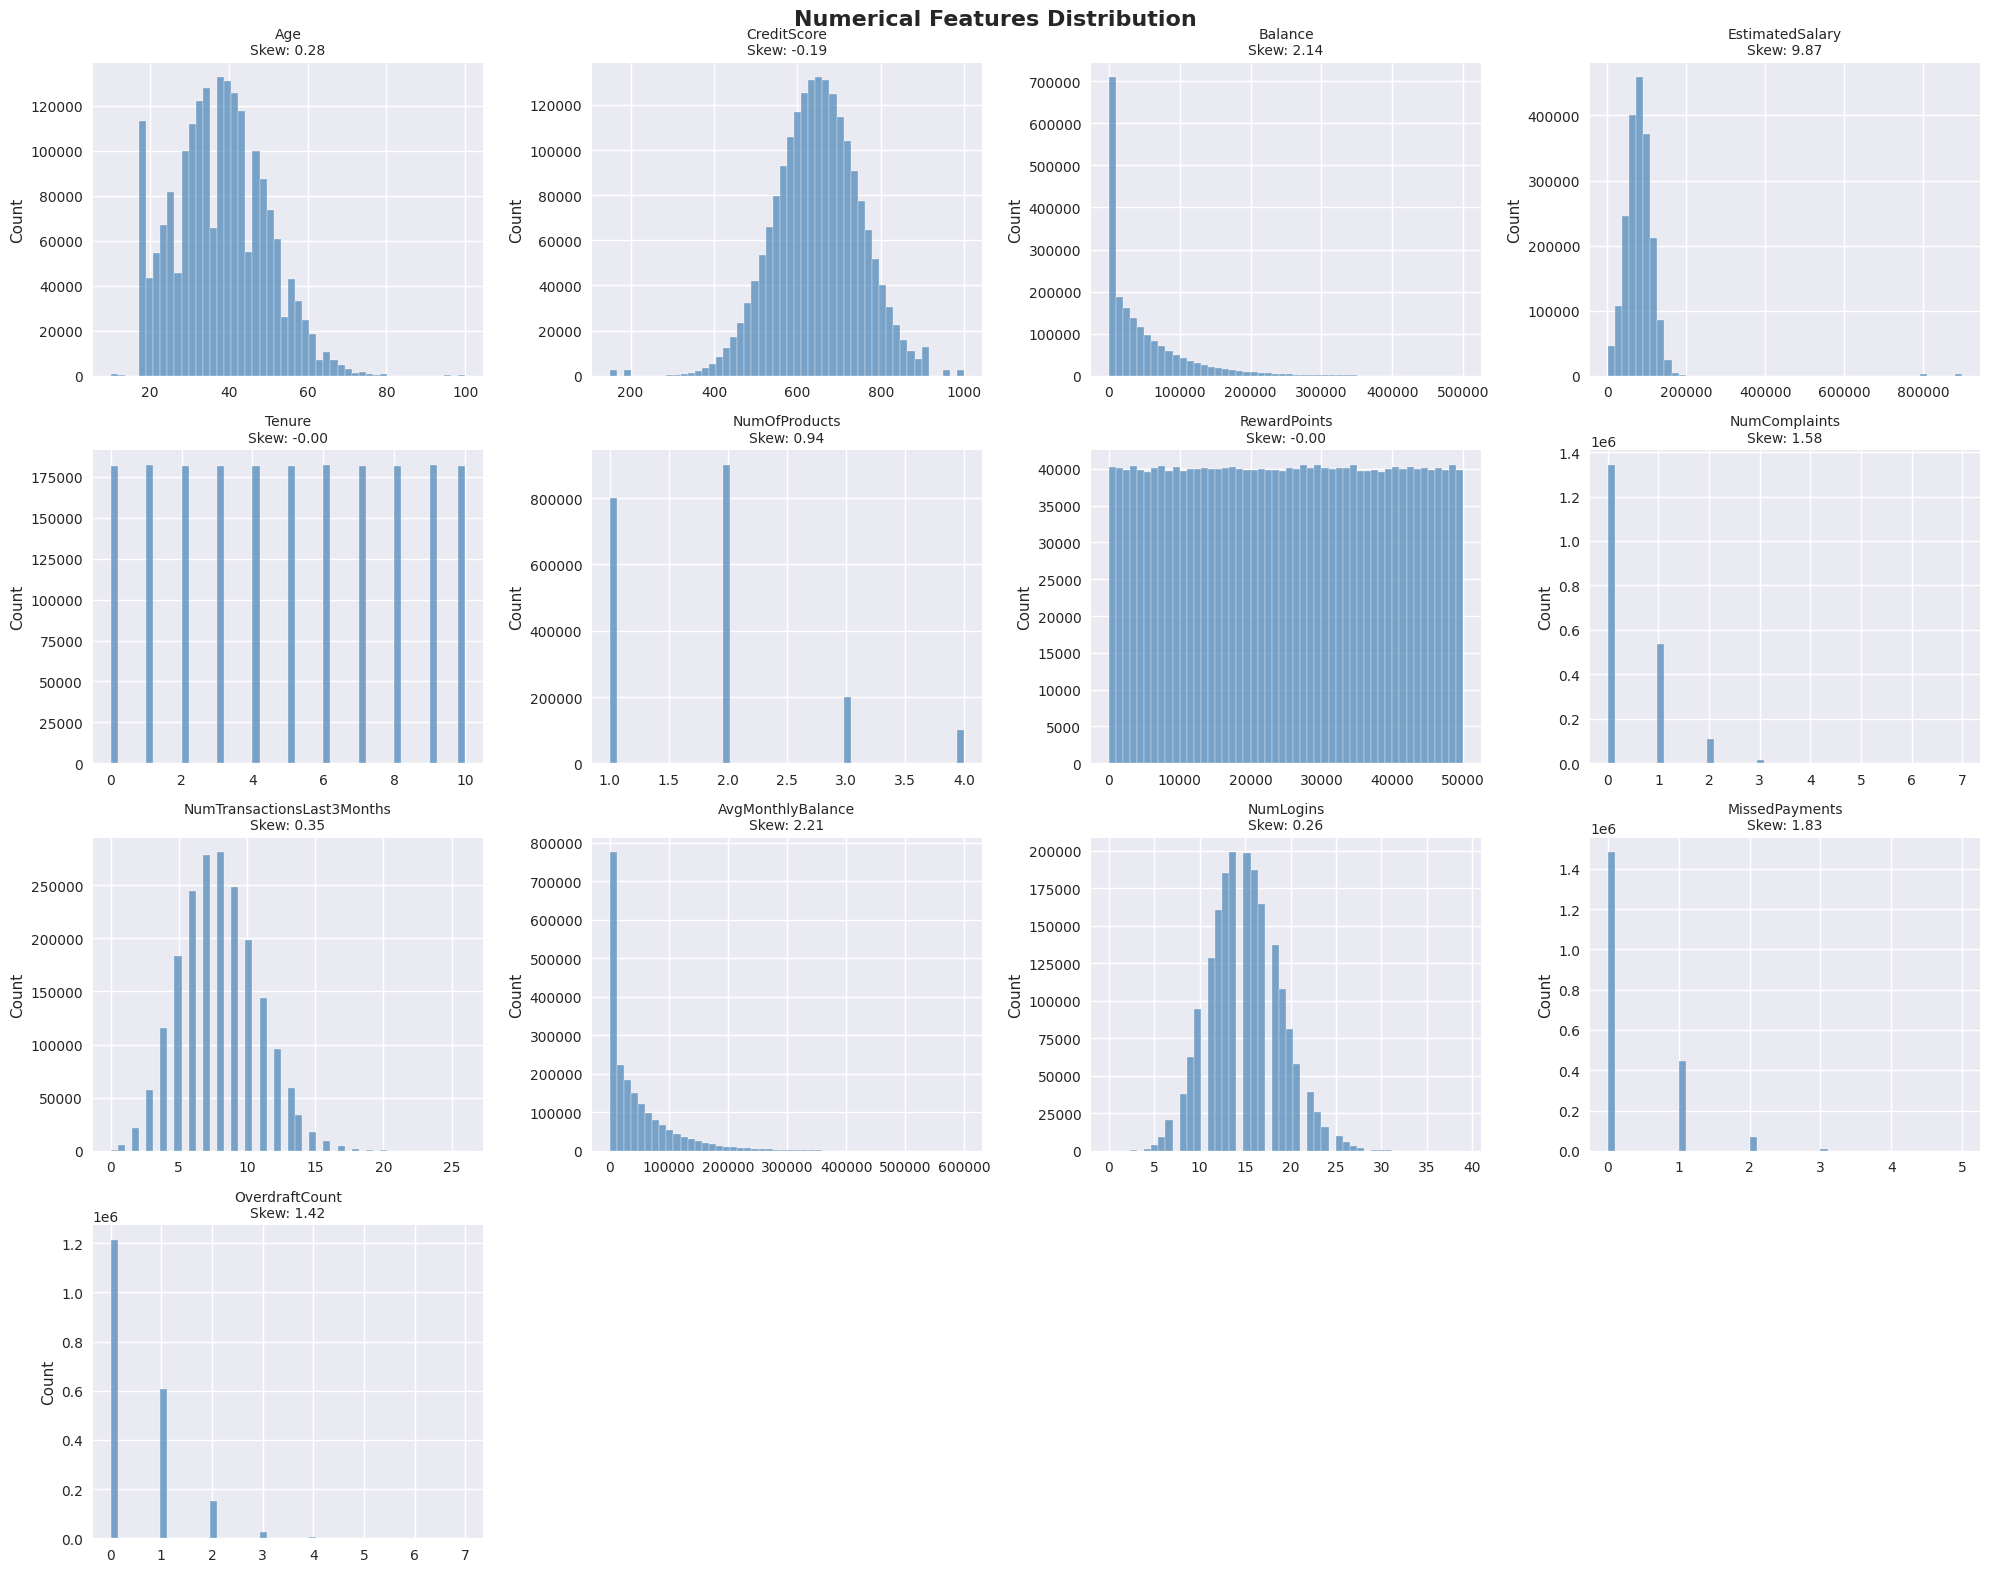


✅ Numerical distributions chart saved!


In [8]:
# ── Cell 7: Numerical Features Distribution ───────────────────────────────────
# Run in JupyterLab to see charts inline
# Interview topic: why do we check distributions?
# Skewed features affect linear models — need normalization
# Outliers affect model training — need treatment

# Select numerical columns excluding IDs and binary flags
numerical_cols = [
    'Age', 'CreditScore', 'Balance', 'EstimatedSalary',
    'Tenure', 'NumOfProducts', 'RewardPoints', 'NumComplaints',
    'NumTransactionsLast3Months', 'AvgMonthlyBalance',
    'NumLogins', 'MissedPayments', 'OverdraftCount'
]

print("=" * 50)
print("NUMERICAL FEATURES — DESCRIPTIVE STATISTICS")
print("=" * 50)
print(df[numerical_cols].describe().round(2))

# Plot distributions
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Drop nulls for plotting
    data = df[col].dropna()
    
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(f'{col}\nSkew: {data.skew():.2f}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/app/notebooks/numerical_distributions.png', dpi=100)
plt.show()

print("\n✅ Numerical distributions chart saved!")

OUTLIER DETECTION — IQR METHOD
                   Lower Bound  Upper Bound  Outlier Count  Outlier %
Column                                                               
Age                       3.50        71.50           5362       0.27
CreditScore             379.50       919.50          16496       0.84
Balance              -98690.94    164484.90          93619       4.82
EstimatedSalary       -1438.46    161508.03          11458       0.58
AvgMonthlyBalance    -98100.54    163500.91          99421       4.97
NumLogins                 3.00        27.00           3366       0.17


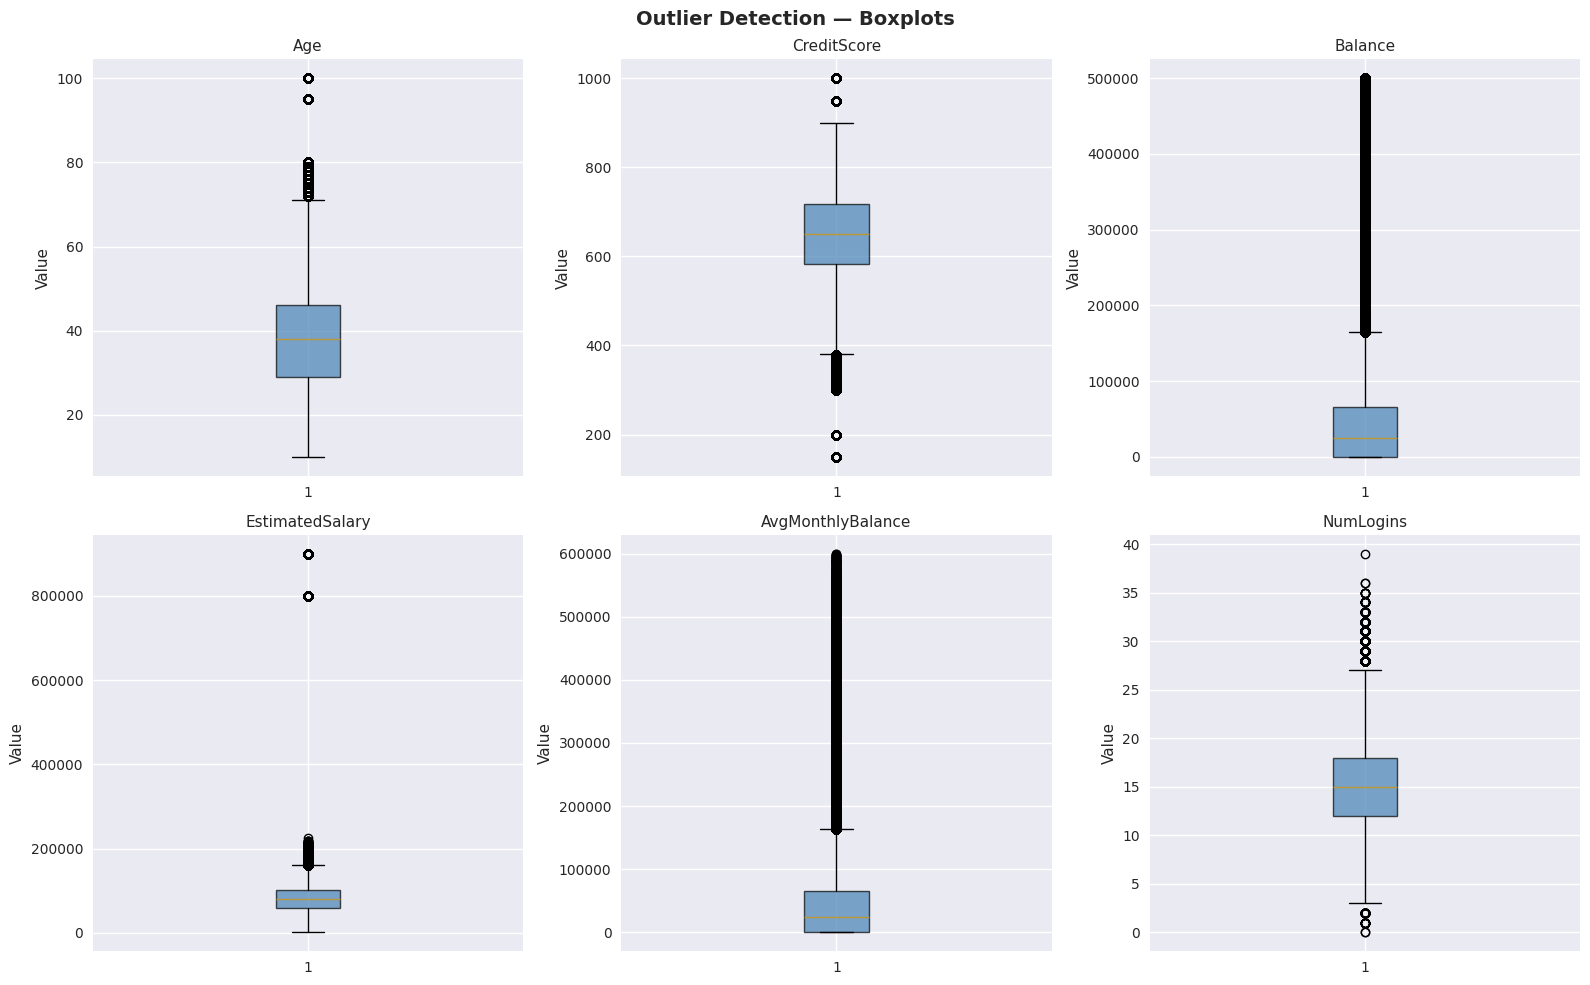


✅ Outlier detection chart saved!


In [9]:
# ── Cell 8: Outlier Detection ─────────────────────────────────────────────────
# Run in JupyterLab to see charts inline
# Two methods: IQR (robust) and Z-score (assumes normality)
# Interview topic: when to use IQR vs Z-score?
# IQR — better for skewed distributions (Balance, Salary)
# Z-score — better for normally distributed features (Age)

print("=" * 50)
print("OUTLIER DETECTION — IQR METHOD")
print("=" * 50)

def detect_outliers_iqr(df, col):
    """
    Detect outliers using IQR method.
    Outlier = value below Q1-1.5*IQR or above Q3+1.5*IQR
    This is the most robust method for skewed distributions.
    """
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    return {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    }

# Check outliers in key numerical columns
outlier_cols = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary',
                'AvgMonthlyBalance', 'NumLogins']

outlier_results = []
for col in outlier_cols:
    result = detect_outliers_iqr(df[df[col].notna()], col)
    result['Column'] = col
    outlier_results.append(result)

outlier_df = pd.DataFrame(outlier_results).set_index('Column')
print(outlier_df[['Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier %']])

# Visualize using boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/app/notebooks/outliers_boxplot.png', dpi=100)
plt.show()

print("\n✅ Outlier detection chart saved!")

CATEGORICAL FEATURES ANALYSIS

Unique value counts per column:
----------------------------------------
Geography                     :   3 unique values
Gender                        :   4 unique values
Occupation                    :  25 unique values
CustomerSegment               :   3 unique values
RiskCategory                  :   3 unique values
LoanType                      :   5 unique values
Channel                       :   5 unique values
PreferredContactMethod        :   4 unique values
DataSource                    :   4 unique values
ModelVersion                  :   3 unique values


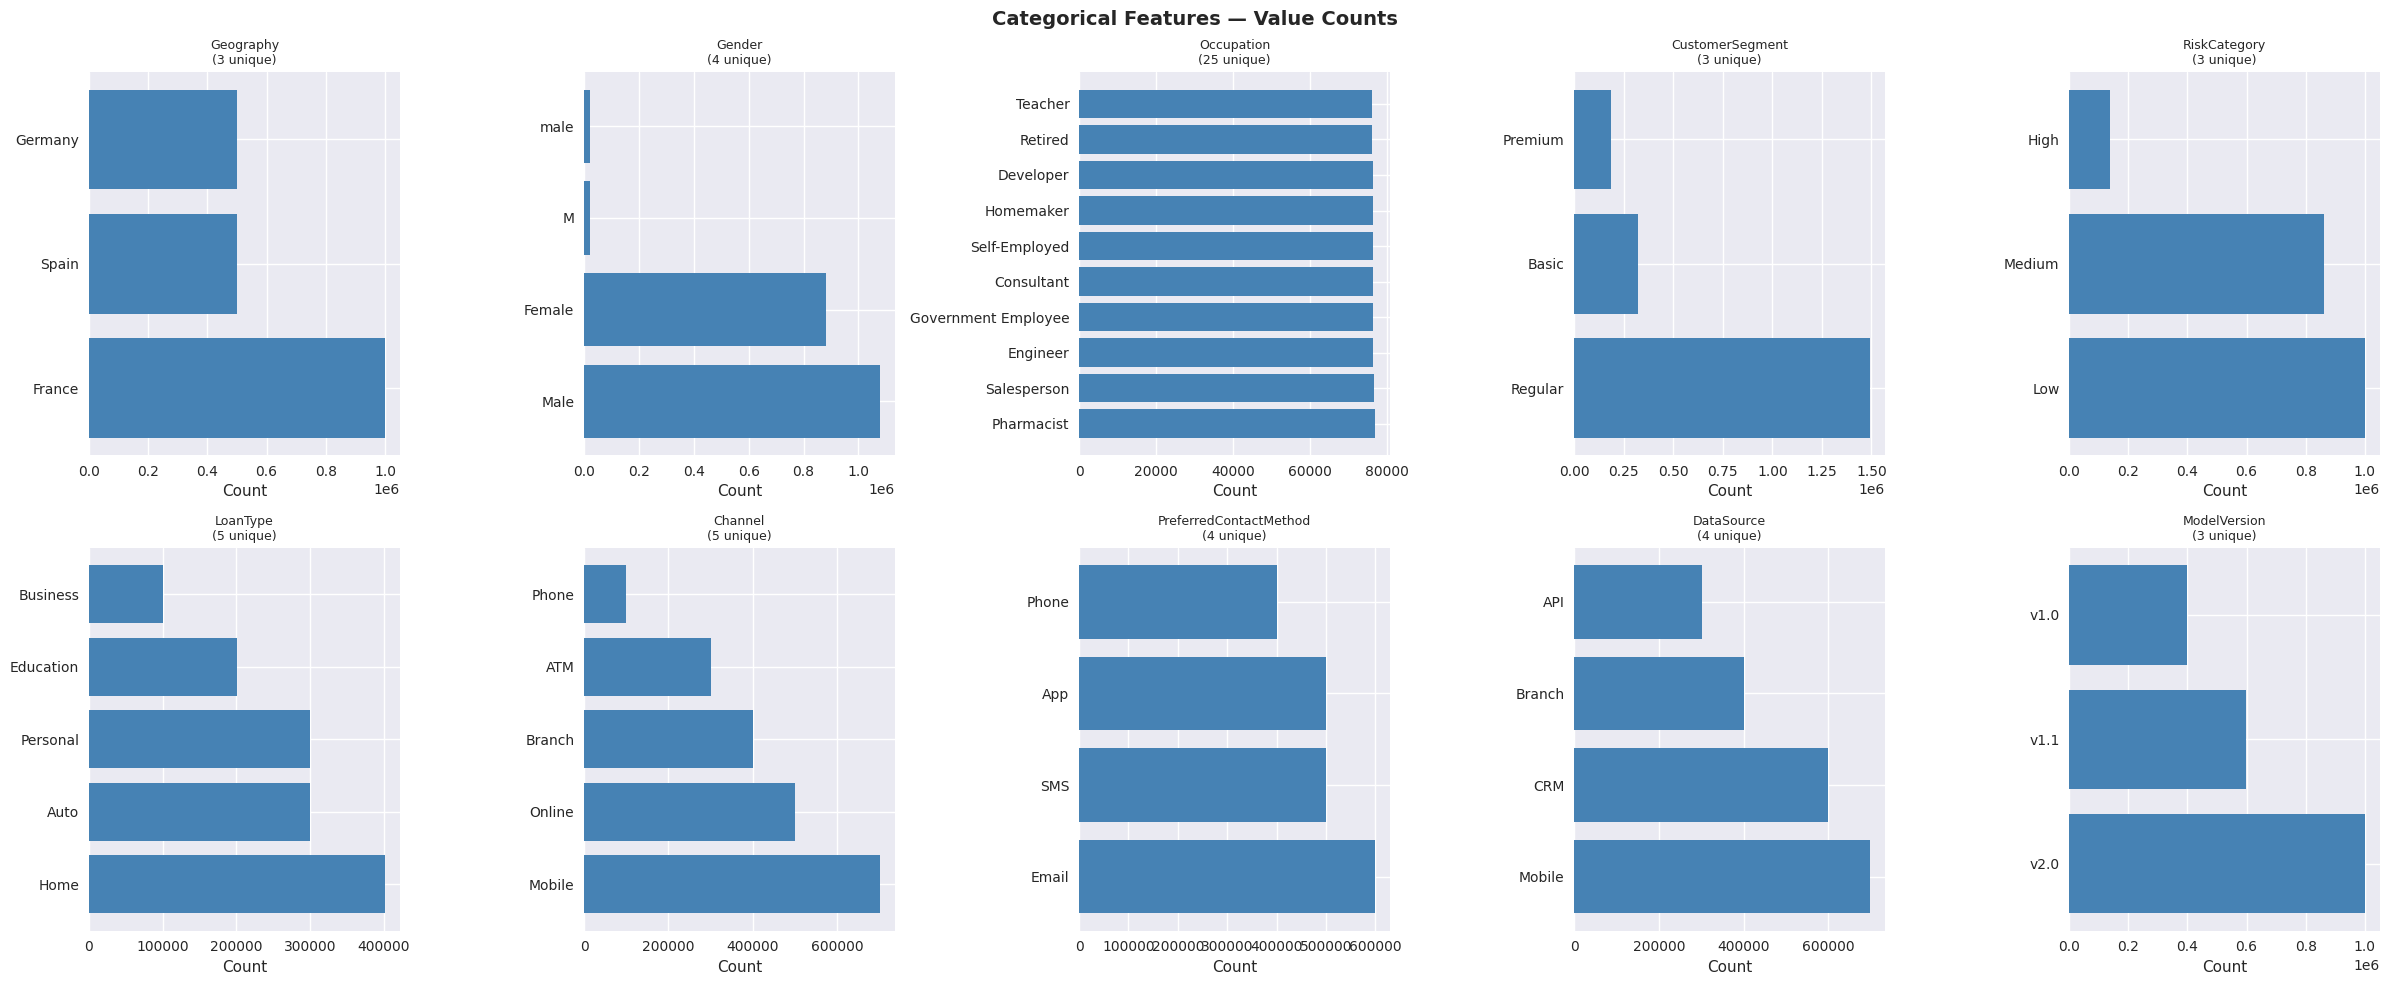


✅ Categorical distributions chart saved!


In [10]:
# ── Cell 9: Categorical Features Analysis ────────────────────────────────────
# Run in JupyterLab to see charts inline
# Interview topic: high cardinality features need special encoding strategies
# Low cardinality → one-hot encoding
# High cardinality → target encoding or frequency encoding

print("=" * 50)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 50)

categorical_cols = [
    'Geography', 'Gender', 'Occupation', 'CustomerSegment',
    'RiskCategory', 'LoanType', 'Channel', 'PreferredContactMethod',
    'DataSource', 'ModelVersion'
]

# Show unique value counts
print("\nUnique value counts per column:")
print("-" * 40)
for col in categorical_cols:
    print(f"{col:30s}: {df[col].nunique():3d} unique values")

# Visualize top categories for each column
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Get top 10 categories by frequency
    top_cats = df[col].value_counts().head(10)
    axes[i].barh(top_cats.index.astype(str), top_cats.values, color='steelblue')
    axes[i].set_title(f'{col}\n({df[col].nunique()} unique)', fontsize=9)
    axes[i].set_xlabel('Count')

plt.suptitle('Categorical Features — Value Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/app/notebooks/categorical_distributions.png', dpi=100)
plt.show()

print("\n✅ Categorical distributions chart saved!")

CHURN RATE BY CATEGORICAL FEATURES

Geography:
Geography
Germany   0.18
Spain     0.13
France    0.13
Name: Exited, dtype: float64

Gender:
Gender
male     0.15
Female   0.15
Male     0.15
M        0.14
Name: Exited, dtype: float64

CustomerSegment:
CustomerSegment
Premium   0.15
Regular   0.15
Basic     0.14
Name: Exited, dtype: float64

RiskCategory:
RiskCategory
High     0.15
Low      0.15
Medium   0.14
Name: Exited, dtype: float64

LoanType:
LoanType
Auto        0.15
Business    0.15
Personal    0.15
Education   0.14
Home        0.14
Name: Exited, dtype: float64

Channel:
Channel
Branch   0.15
Online   0.15
Mobile   0.15
Phone    0.14
ATM      0.14
Name: Exited, dtype: float64

NumOfProducts:
NumOfProducts
1   0.20
2   0.11
3   0.11
4   0.11
Name: Exited, dtype: float64

HasCrCard:
HasCrCard
0   0.17
1   0.14
Name: Exited, dtype: float64

IsActiveMember:
IsActiveMember
0   0.19
1   0.12
Name: Exited, dtype: float64


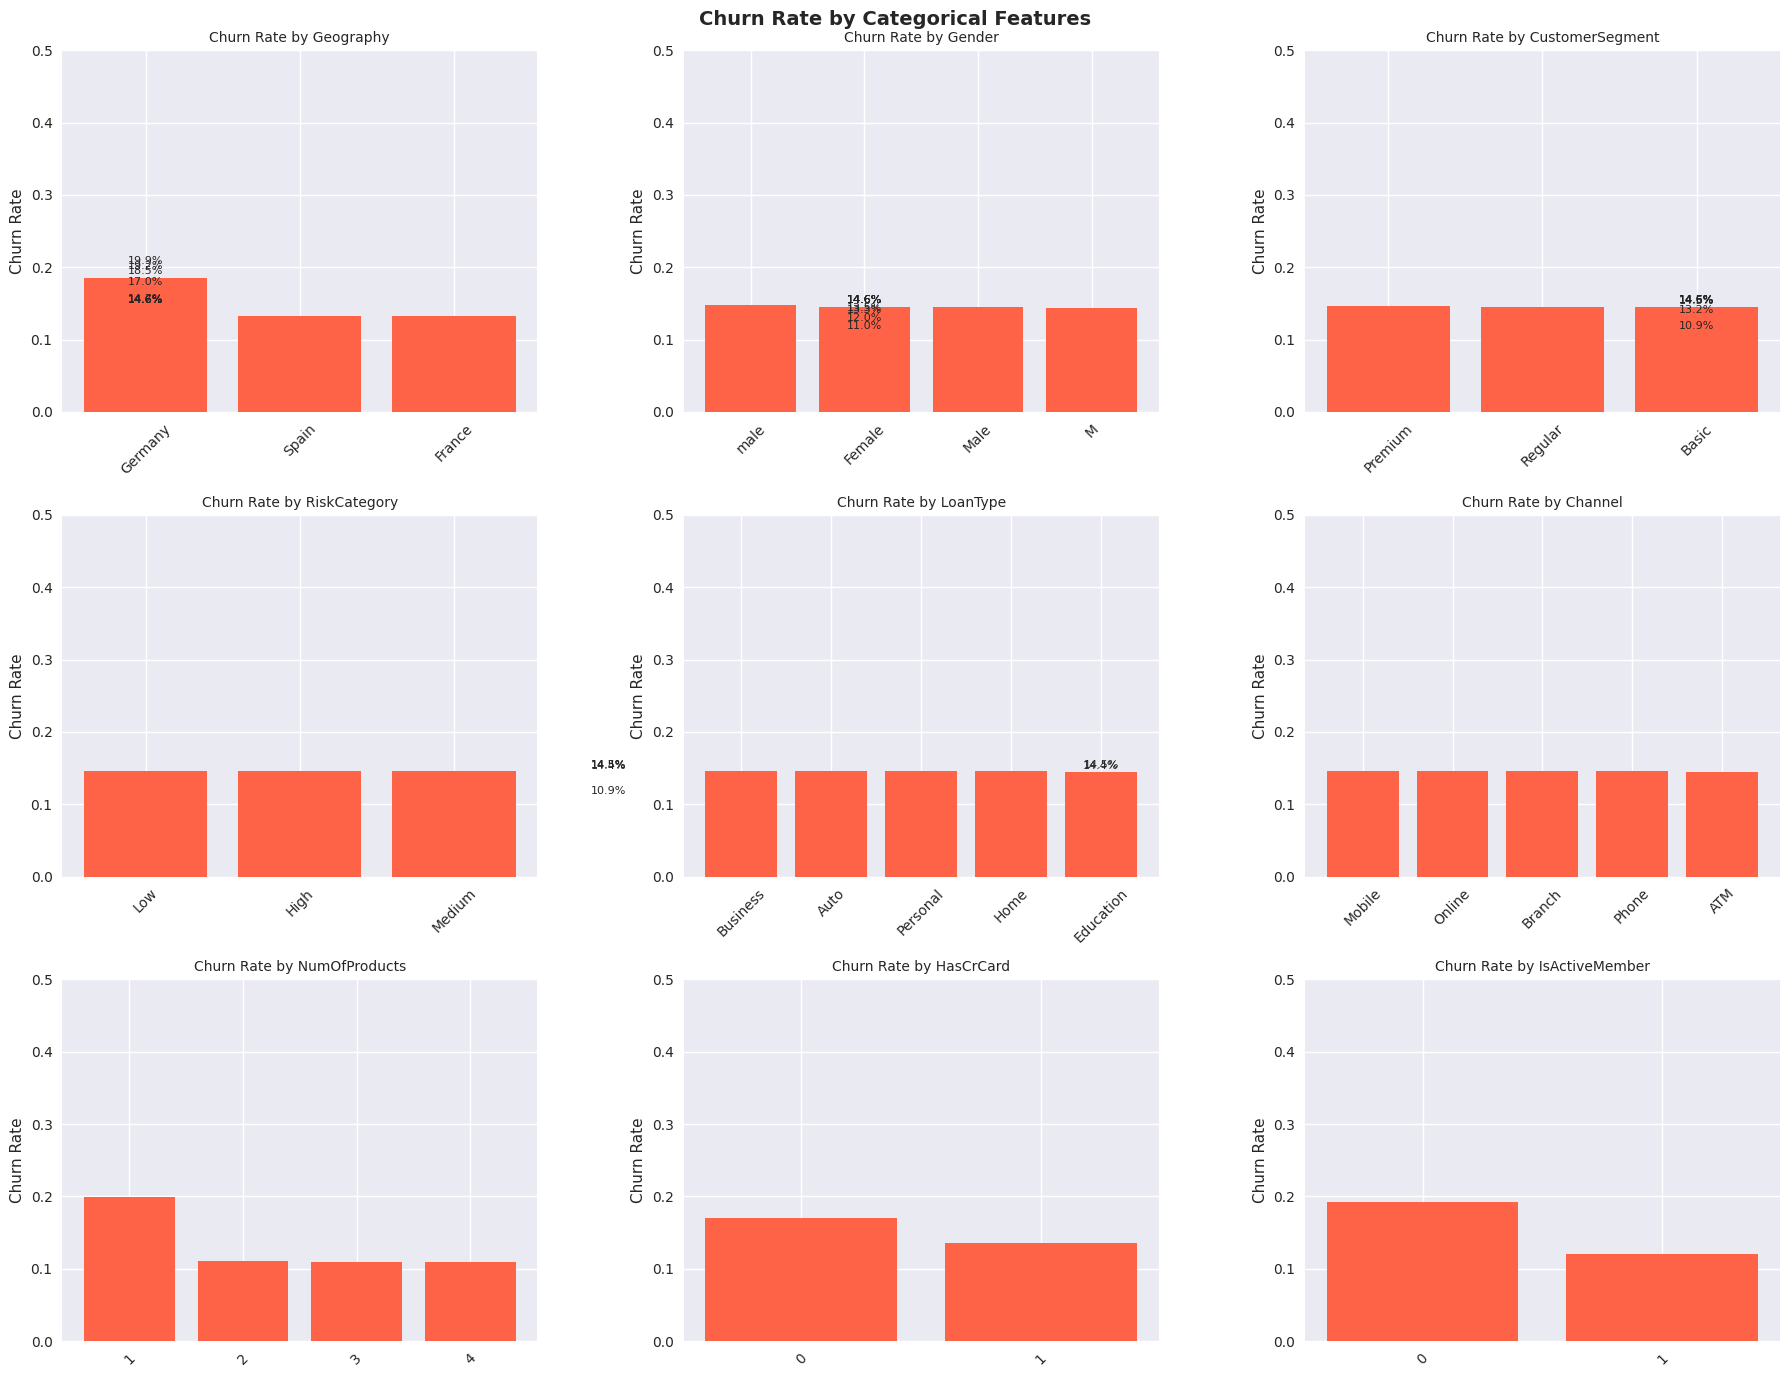


✅ Churn rate by category chart saved!


In [11]:
# ── Cell 10: Churn Rate by Category ──────────────────────────────────────────
# Run in JupyterLab to see charts inline
# This is the MOST important EDA for a churn project
# Interview topic: which features are most predictive of churn?
# We look at churn RATE per category, not just counts

print("=" * 50)
print("CHURN RATE BY CATEGORICAL FEATURES")
print("=" * 50)

churn_cat_cols = [
    'Geography', 'Gender', 'CustomerSegment',
    'RiskCategory', 'LoanType', 'Channel',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember'
]

# Print churn rates
for col in churn_cat_cols:
    print(f"\n{col}:")
    print(df.groupby(col)['Exited'].mean().round(3).sort_values(ascending=False))

# Visualize
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(churn_cat_cols):
    churn_rate = df.groupby(col)['Exited'].mean().sort_values(ascending=False)
    axes[i].bar(churn_rate.index.astype(str), churn_rate.values, color='tomato')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=10)
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 0.5)
    axes[i].tick_params(axis='x', rotation=45)
    # Add value labels on bars
    for j, v in enumerate(churn_rate.values):
        axes[j].text(j, v + 0.005, f'{v:.1%}', ha='center', fontsize=8) if i == i else None

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/app/notebooks/churn_rate_by_category.png', dpi=100)
plt.show()

print("\n✅ Churn rate by category chart saved!")

CORRELATION ANALYSIS

Top correlations with Exited (target):
NumOfProducts           -0.10
Age                      0.05
Balance                 -0.05
AvgMonthlyBalance       -0.05
SavingsAccountBalance   -0.05
TotalProductValue       -0.05
Tenure                  -0.04
NumComplaints            0.01
RewardPoints             0.00
EstimatedSalary          0.00
Name: Exited, dtype: float64

⚠️  Highly correlated feature pairs (|corr| > 0.7):
               Feature 1              Feature 2  Correlation
0                Balance      AvgMonthlyBalance         0.99
1                Balance  SavingsAccountBalance         0.90
2                Balance      TotalProductValue         0.97
3      AvgMonthlyBalance  SavingsAccountBalance         0.89
4      AvgMonthlyBalance      TotalProductValue         0.96
5  SavingsAccountBalance      TotalProductValue         0.92


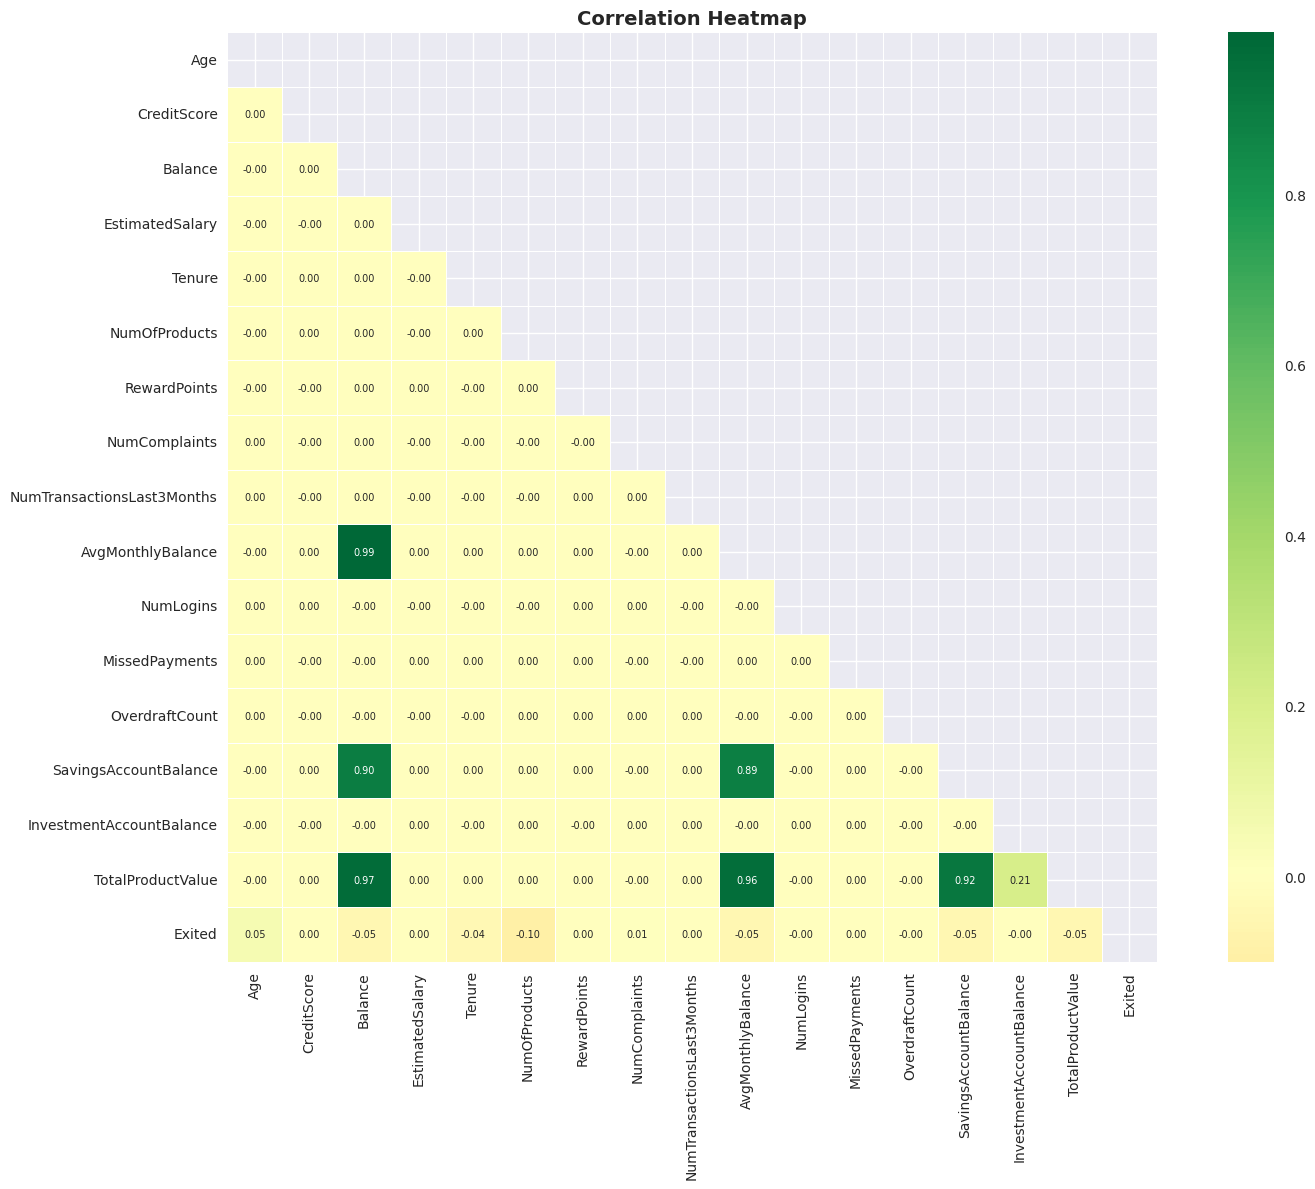


✅ Correlation heatmap saved!


In [12]:
# ── Cell 11: Correlation Analysis ─────────────────────────────────────────────
# Run in JupyterLab to see heatmap inline
# Interview topic: why does multicollinearity matter?
# Correlated features don't add new info but increase model complexity
# Linear models are especially affected — tree models less so

print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)

# Select numerical columns for correlation
corr_cols = [
    'Age', 'CreditScore', 'Balance', 'EstimatedSalary',
    'Tenure', 'NumOfProducts', 'RewardPoints', 'NumComplaints',
    'NumTransactionsLast3Months', 'AvgMonthlyBalance',
    'NumLogins', 'MissedPayments', 'OverdraftCount',
    'SavingsAccountBalance', 'InvestmentAccountBalance',
    'TotalProductValue', 'Exited'
]

# Compute correlation matrix
corr_matrix = df[corr_cols].corr().round(2)

# Print top correlations with target
print("\nTop correlations with Exited (target):")
target_corr = corr_matrix['Exited'].drop('Exited').sort_values(key=abs, ascending=False)
print(target_corr.head(10))

# Print highly correlated feature pairs (multicollinearity)
print("\n⚠️  Highly correlated feature pairs (|corr| > 0.7):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i,j]
            })

if high_corr_pairs:
    print(pd.DataFrame(high_corr_pairs))
else:
    print("No highly correlated pairs found above 0.7 threshold")

# Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/app/notebooks/correlation_heatmap.png', dpi=100)
plt.show()

print("\n✅ Correlation heatmap saved!")


In [13]:
# ── Cell 12: EDA Summary ──────────────────────────────────────────────────────
# Run in JupyterLab
# Summarize all findings in one place
# In interviews — always summarize EDA findings before talking about cleaning
# Shows structured thinking

print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

print("""
📊 DATASET
   • 2,000,500 rows × 44 columns
   • Memory: 2,713 MB — needs dtype optimization
   • Churn rate: 14.6% — class imbalance (5.9:1 ratio)

🔴 DATA QUALITY ISSUES FOUND
   • Missing values in 8 columns
     - LoanType: 34.97% missing → treat as 'No Loan' category
     - Occupation: 4.97% → mode/unknown imputation
     - LastTransactionDate: 4.02% → median date imputation
     - Balance, City, NumLogins, CreditScore, EstimatedSalary: 2-3%
   • 500 exact duplicate rows → remove
   • Gender has 4 values instead of 2 → standardize
   • Age has impossible values (10, 100) → business rule fix
   • CreditScore outliers beyond 300-900 → cap/remove
   • EstimatedSalary extreme outliers → IQR capping
   • Date columns stored as object → parse to datetime
   • Mixed date formats in AccountOpenDate → standardize

📈 KEY PREDICTORS OF CHURN
   • NumOfProducts — single product customers churn 20% vs 11%
   • IsActiveMember — inactive customers churn 19% vs 12%
   • Geography — Germany 18% vs France/Spain 13%
   • HasCrCard — no card = 17% churn vs 14%
   • Age — older customers churn more

⚠️  MULTICOLLINEARITY DETECTED
   • Balance, AvgMonthlyBalance, SavingsAccountBalance,
     TotalProductValue all correlated > 0.90
   • Action: keep Balance, drop the rest during feature selection

🎯 NEXT STEPS
   1. Data Cleaning — fix all issues found above
   2. Feature Engineering — create new predictive features
   3. Encoding — handle categorical columns
   4. Class Imbalance — SMOTE / class weights
   5. Model Building — Logistic → XGBoost → Ensemble
""")

print("✅ EDA Complete! Moving to Data Cleaning next.")

EDA SUMMARY — KEY FINDINGS

📊 DATASET
   • 2,000,500 rows × 44 columns
   • Memory: 2,713 MB — needs dtype optimization
   • Churn rate: 14.6% — class imbalance (5.9:1 ratio)

🔴 DATA QUALITY ISSUES FOUND
   • Missing values in 8 columns
     - LoanType: 34.97% missing → treat as 'No Loan' category
     - Occupation: 4.97% → mode/unknown imputation
     - LastTransactionDate: 4.02% → median date imputation
     - Balance, City, NumLogins, CreditScore, EstimatedSalary: 2-3%
   • 500 exact duplicate rows → remove
   • Gender has 4 values instead of 2 → standardize
   • Age has impossible values (10, 100) → business rule fix
   • CreditScore outliers beyond 300-900 → cap/remove
   • EstimatedSalary extreme outliers → IQR capping
   • Date columns stored as object → parse to datetime
   • Mixed date formats in AccountOpenDate → standardize

📈 KEY PREDICTORS OF CHURN
   • NumOfProducts — single product customers churn 20% vs 11%
   • IsActiveMember — inactive customers churn 19% vs 12%
   • 